In [103]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

In [104]:
def load_flo(filename):
    with open(filename, 'rb') as f:
        magic = np.fromfile(f, np.float32, count=1)
        if magic != 202021.25:
            raise ValueError('Format .flo invalide ou corrompu')

        width = np.fromfile(f, np.int32, count=1)[0]
        height = np.fromfile(f, np.int32, count=1)[0]
        data = np.fromfile(f, np.float32, count=2 * width * height)
        flow = np.resize(data, (height, width, 2))

    return flow

In [105]:
# Charger un fichier .flo
flow = load_flo("output_flows/out_100.flo")


print("Taille de l'image :", flow.shape)  # (hauteur, largeur, 2)
print("Exemple de vecteur de mouvement :", flow[0, 0])  # Vecteur de mouvement à la position (0, 0)

Taille de l'image : (1440, 2304, 2)
Exemple de vecteur de mouvement : [-2.103034    0.10798922]


In [106]:
def flow_to_image(flow):
    h, w = flow.shape[:2]
    hsv = np.zeros((h, w, 3), dtype=np.uint8)

    # Calcul de la magnitude et de l'angle du mouvement
    mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])

    # Teinte (H) basée sur l'angle du mouvement
    hsv[..., 0] = ang * 180 / np.pi / 2
    # Saturation maximale
    hsv[..., 1] = 255
    # Valeur (V) basée sur l'intensité du mouvement (normalisée)
    hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)

    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

Bleu → Mouvement vers la droite.

Rouge → Mouvement vers la gauche.

Vert → Mouvement vers le haut.

Jaune → Mouvement vers le bas.

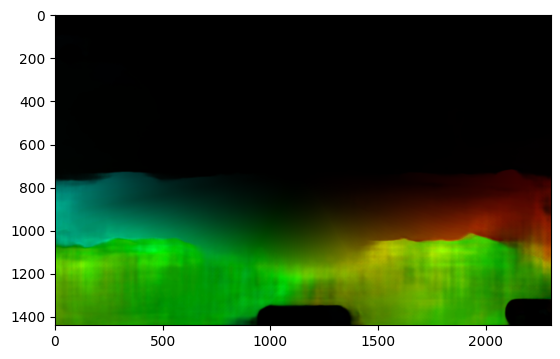

In [107]:
flow_image = flow_to_image(flow)

plt.imshow(cv2.cvtColor(flow_image, cv2.COLOR_BGR2RGB))

In [108]:
def plot_optical_flow(flow, step=16):
    """
    Affiche le champ de flux optique avec des flèches.

    :param flow: Tableau numpy (H, W, 2).
    :param step: Espacement entre les flèches.
    """
    h, w = flow.shape[:2]
    y, x = np.mgrid[step//2:h:step, step//2:w:step]  # Création de la grille
    u, v = flow[y, x, 0], flow[y, x, 1]  # Extraction des vecteurs (u, v)

    plt.figure(figsize=(8, 6))
    plt.imshow(np.zeros((h, w)), cmap="gray")  # Fond noir
    plt.quiver(x, y, u, v, color='red', angles='xy', scale_units='xy', scale=1)
    plt.axis("off")
    plt.show()

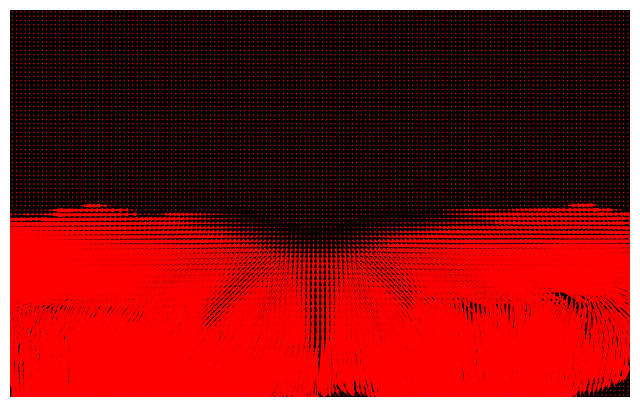

In [109]:
# Affichage des flèches
plot_optical_flow(flow)


In [110]:
def mean_optical_flow(flow):
    """
    Calcule la moyenne des déplacements horizontaux (u) et verticaux (v) dans un champ de flux optique.

    :param flow: Tableau numpy (H, W, 2) contenant les vecteurs (u, v).
    :return: Tuple (moyenne_u, moyenne_v)
    """

    # Récupérer le flux pour seulement la moitié de l'image
    flow = flow[flow.shape[0]//4:3*flow.shape[0]//4, flow.shape[1]//4:3*flow.shape[1]//4] # (H//2, W//2, 2)

    # Séparer les composantes du flux
    u = flow[..., 0]  # Déplacement horizontal
    v = flow[..., 1]  # Déplacement vertical

    # Calcul des moyennes
    mean_u = np.mean(u)  # Moyenne des déplacements horizontaux
    mean_v = np.mean(v)  # Moyenne des déplacements verticaux

    return mean_u, mean_v

In [111]:
def mean_optical_flow_weighted(flow, alpha=0.5):
    """
    Calcule le flux optique moyen en attribuant un poids plus fort aux mouvements brusques.

    :param flow: Champ de flux optique (h, w, 2) avec (u,v) en chaque pixel
    :param alpha: Facteur d'importance des grands mouvements (ajuste la sensibilité)
    :return: Moyenne pondérée du déplacement horizontal (u) et vertical (v)
    """

    # Récupérer le flux pour seulement la moitié de l'image
    flow = flow[flow.shape[0]//4:3*flow.shape[0]//4, flow.shape[1]//4:3*flow.shape[1]//4] # (H//2, W//2, 2)

    u = flow[:, :, 0]
    v = flow[:, :, 1]

    # Calculer la norme du mouvement ||M||
    norm = np.sqrt(u**2 + v**2)

    # Définir un poids en fonction de la norme (plus grand si le mouvement est brusque)
    weights = np.exp(alpha * norm / np.max(norm))  # Exponentiel pour amplifier les gros déplacements

    # Moyenne pondérée
    mean_u = np.sum(weights * u) / np.sum(weights)
    mean_v = np.sum(weights * v) / np.sum(weights)

    return mean_u, mean_v


In [112]:
mean_u, mean_v = mean_optical_flow(flow)
print(f"Moyenne des déplacements horizontaux (u) : {mean_u:.4f}")
print(f"Moyenne des déplacements verticaux (v) : {mean_v:.4f}")

Moyenne des déplacements horizontaux (u) : -0.2504
Moyenne des déplacements verticaux (v) : 15.3356


In [113]:
mean_u_w, mean_v_w = mean_optical_flow_weighted(flow)
print(f"Moyenne pondérée des déplacements horizontaux (u) : {mean_u_w:.4f}")
print(f"Moyenne pondérée des déplacements verticaux (v) : {mean_v_w:.4f}")

Moyenne pondérée des déplacements horizontaux (u) : -0.3453
Moyenne pondérée des déplacements verticaux (v) : 17.9151
